
===== Student Performance System =====
1. Add Student Data
2. Train Model (Shows Graphs)
3. Predict Marks
4. Exit
Enter choice: 1
Enter student name: palak
Hours studied: 5
Attendance (%): 60
Sleep hours: 8
Previous score: 70
Internet usage (hrs): 3
Marks: 80
✅ Student data added!

===== Student Performance System =====
1. Add Student Data
2. Train Model (Shows Graphs)
3. Predict Marks
4. Exit
Enter choice: 2


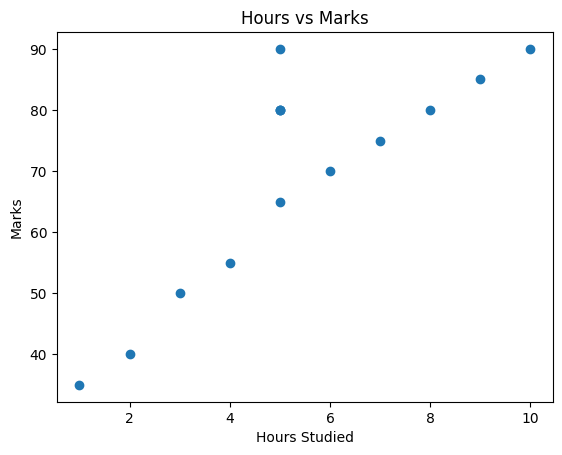

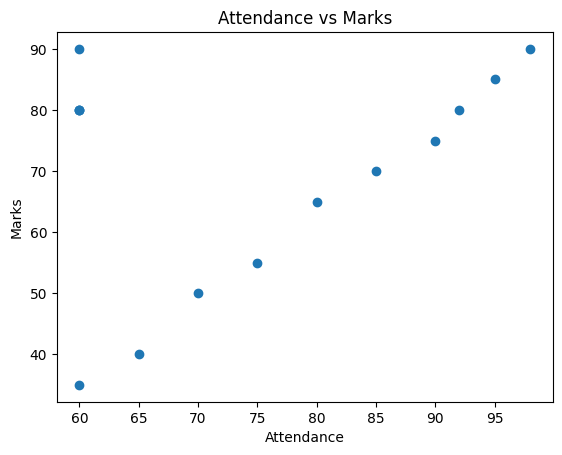

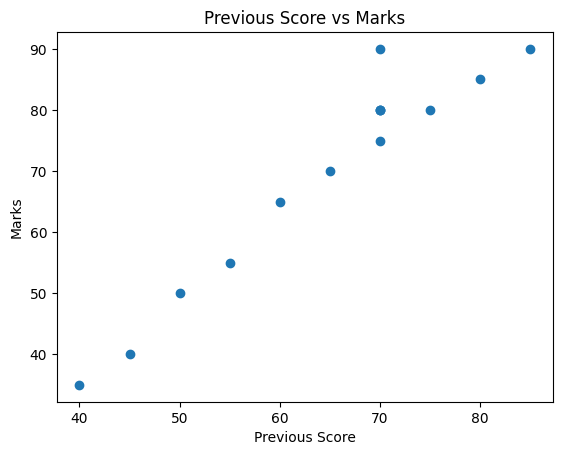

📈 Model trained! R2 Score: 0.95

===== Student Performance System =====
1. Add Student Data
2. Train Model (Shows Graphs)
3. Predict Marks
4. Exit
Enter choice: 3
84.29

===== Student Performance System =====
1. Add Student Data
2. Train Model (Shows Graphs)
3. Predict Marks
4. Exit
Enter choice: 4
👋 Exiting...


In [6]:
# =====================================
# Student Performance System (Final)
# =====================================

import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

FILE_NAME = "student_data.csv"

# -------------------------------------
# Create file if not exists
# -------------------------------------
if not os.path.exists(FILE_NAME):
    df = pd.DataFrame(columns=[
        "Student_Name", "Hours_Studied", "Attendance",
        "Sleep_Hours", "Previous_Score", "Internet_Usage", "Marks"
    ])
    df.to_csv(FILE_NAME, index=False)

# =====================================
# Add Student Data
# =====================================
def add_student():
    name = input("Enter student name: ")
    hours = float(input("Hours studied: "))
    attendance = float(input("Attendance (%): "))
    sleep = float(input("Sleep hours: "))
    prev = float(input("Previous score: "))
    internet = float(input("Internet usage (hrs): "))
    marks = float(input("Marks: "))

    new_data = pd.DataFrame([[name, hours, attendance, sleep, prev, internet, marks]],
                            columns=[
                                "Student_Name", "Hours_Studied", "Attendance",
                                "Sleep_Hours", "Previous_Score", "Internet_Usage", "Marks"
                            ])

    df = pd.read_csv(FILE_NAME)
    df = pd.concat([df, new_data], ignore_index=True)
    df.to_csv(FILE_NAME, index=False)

    print("✅ Student data added!")

# =====================================
# Train Model + Graphs
# =====================================
def train_model():
    df = pd.read_csv(FILE_NAME)

    if len(df) < 3:
        print("⚠ Not enough data to train model (add more students).")
        return None, None

    # -------- VISUALIZATION --------
    plt.scatter(df["Hours_Studied"], df["Marks"])
    plt.xlabel("Hours Studied")
    plt.ylabel("Marks")
    plt.title("Hours vs Marks")
    plt.show()

    plt.scatter(df["Attendance"], df["Marks"])
    plt.xlabel("Attendance")
    plt.ylabel("Marks")
    plt.title("Attendance vs Marks")
    plt.show()

    plt.scatter(df["Previous_Score"], df["Marks"])
    plt.xlabel("Previous Score")
    plt.ylabel("Marks")
    plt.title("Previous Score vs Marks")
    plt.show()

    # -------- MODEL --------
    X = df[["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Score", "Internet_Usage"]]
    y = df["Marks"]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)

    print(f"📈 Model trained! R2 Score: {score:.2f}")

    return model, scaler

# =====================================
# Predict Marks (ONLY ONE OUTPUT)
# =====================================
def predict_marks(model, scaler):
    if model is None:
        print("⚠ Train model first!")
        return

    df = pd.read_csv(FILE_NAME)

    # Take last student only
    last_student = df.tail(1)

    X = last_student[["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Score", "Internet_Usage"]]

    X_scaled = scaler.transform(X)

    prediction = model.predict(X_scaled)

    # ONLY ONE MARK
    print(f"{prediction[0]:.2f}")

# =====================================
# Main Menu
# =====================================
def main():
    model = None
    scaler = None

    while True:
        print("\n===== Student Performance System =====")
        print("1. Add Student Data")
        print("2. Train Model (Shows Graphs)")
        print("3. Predict Marks")
        print("4. Exit")

        choice = input("Enter choice: ")

        if choice == "1":
            add_student()
        elif choice == "2":
            model, scaler = train_model()
        elif choice == "3":
            predict_marks(model, scaler)
        elif choice == "4":
            print("👋 Exiting...")
            break
        else:
            print("❌ Invalid choice")

# Run program
if __name__ == "__main__":
    main()